# DTs

## residual method

In [2]:
import os

# Base directory where we think the data starts
SEARCH_BASE = "/Users/glsw/main/NucMLClone2/Evaluated_Data"

print(f"Searching for 'Am241' (or 'Am-241') files in: {SEARCH_BASE}...")

found_files = []

for root, dirs, files in os.walk(SEARCH_BASE):
    for file in files:
        # We are looking for Fission (MT18 or mt18) and Am241
        if "Am241" in file or "Am-241" in file:
             if "mt18" in file.lower() or "mt018" in file.lower():
                full_path = os.path.join(root, file)
                found_files.append(full_path)

if found_files:
    print("\nSUCCESS! Found these potential files:")
    for f in found_files:
        print(f"--> {f}")
else:
    print("\nNo exact matches found. Listing ALL files in the Am241 folder (if it exists):")
    # Fallback: List anything in an Am241 folder
    for root, dirs, files in os.walk(SEARCH_BASE):
        if "Am241" in root or "Am-241" in root:
            print(f"\nIn folder: {root}")
            print(files[:5]) # Show first 5 files

Searching for 'Am241' (or 'Am-241') files in: /Users/glsw/main/NucMLClone2/Evaluated_Data...

SUCCESS! Found these potential files:
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/protons/Am241/tendl.2019/tables/xs/p-Am241-MT018.tendl.2019
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/jeff3.3/tables/xs/n-Am241-MT018.jeff3.3
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/jeff3.3/tables/xs/n-Am241-MT018-G700.jeff3.3
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/jeff3.3/tables/xs/n-Am241-MT018-G069.jeff3.3
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/jeff3.3/tables/xs/n-Am241-MT018-G171.jeff3.3
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018-G700.tendl.2019
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018-G171.tendl.2019
--> /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import gc
import os

# --- UPDATED PATH (Based on your search results) ---
# We chose the standard point-wise file (no G171/G700 suffix)
PATH_EVAL = "/Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0"

PATH_EXFOR = "./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"

TARGET_Z, TARGET_A, TARGET_MT = 95, 241, 18
CUTOFF_EV = 1e5  # 100 keV

print(f"Targeting Eval File: {os.path.basename(PATH_EVAL)}")

# --- LOAD DATA ---
if not os.path.exists(PATH_EVAL):
    print(f"CRITICAL ERROR: File still not found at: {PATH_EVAL}")
else:
    # 1. Load Evaluation
    # These files usually have multiple columns, we just want the first 2 (Energy, Sigma)
    df_eval = pd.read_csv(PATH_EVAL, sep='\s+', comment='#', header=None)
    df_eval = df_eval.iloc[:, :2].copy()
    df_eval.columns = ['energy', 'sigma']

    # 2. Unit Detection & Fix
    # If max energy is small (< 50), it's likely MeV. Convert to eV.
    if df_eval['energy'].max() < 50:
        print("-> Detected MeV units. Converting to eV...")
        df_eval['energy'] *= 1e6
    else:
        print("-> Detected eV units.")

    # 3. Filter Fast Region
    df_eval = df_eval[df_eval['energy'] > CUTOFF_EV].copy()
    
    # 4. Log Transforms
    df_eval['log_e'] = np.log10(df_eval['energy'])
    df_eval['log_xs_eval'] = np.log10(df_eval['sigma'])

    print(f"Success! Eval loaded: {len(df_eval)} points.")
    display(df_eval.head(3))

Targeting Eval File: n-Am241-MT018.endfb8.0
-> Detected MeV units. Converting to eV...
Success! Eval loaded: 211 points.


,energy,sigma,log_e,log_xs_eval
16083,101411.0,15.9213,5.006085,1.201979
16084,110776.0,15.7128,5.044446,1.196254
16085,115000.0,15.6901,5.060698,1.195626


In [4]:
# --- CELL 2.2: LOAD EXFOR DATA ---
import pandas as pd
import numpy as np
import gc

print("Loading EXFOR Data...")

# 1. Read the CSV
# We use low_memory=False because the file is large mixed types
df_all = pd.read_csv(PATH_EXFOR, low_memory=False)

# 2. Filter for Am-241 (n,f)
df_exp = df_all[
    (df_all['Z'] == TARGET_Z) & 
    (df_all['A'] == TARGET_A) & 
    (df_all['MT'] == TARGET_MT)
].copy()

# 3. Clean up memory
del df_all
gc.collect()

# 4. Standardize Columns
# Rename to match df_eval: 'Energy' -> 'energy', 'Data' -> 'sigma'
df_exp.rename(columns={'Energy': 'energy', 'Data': 'sigma'}, inplace=True)

# 5. Filter Fast Region & Valid Data
df_exp = df_exp[df_exp['energy'] > CUTOFF_EV].copy()
df_exp = df_exp[df_exp['sigma'] > 0].copy() 

# 6. Log Transforms (Crucial for learning scaling laws)
df_exp['log_e'] = np.log10(df_exp['energy'])
df_exp['log_xs_exp'] = np.log10(df_exp['sigma'])

print(f"SUCCESS: Loaded {len(df_exp)} experimental data points.")
display(df_exp[['energy', 'sigma', 'log_e', 'log_xs_exp']].head())

Loading EXFOR Data...
SUCCESS: Loaded 609 experimental data points.


,energy,sigma,log_e,log_xs_exp
4252274,120000.0,0.020,5.079181,-1.698970
4252275,140000.0,0.022,5.146128,-1.657577
4252276,160000.0,0.024,5.204120,-1.619789
4252277,180000.0,0.027,5.255273,-1.568636
4252278,200000.0,0.030,5.301030,-1.522879


In [5]:
# --- CELL 2.3: CALCULATE RESIDUALS ---

# 1. Interpolate Theory onto Experimental Grid
# "What does ENDF say the cross section is at these exact experimental energies?"
interp_theory_vals = np.interp(
    df_exp['log_e'],       # Target X (Experiment)
    df_eval['log_e'],      # Source X (Library)
    df_eval['log_xs_eval'] # Source Y (Library)
)

# 2. Calculate Residual
# Residual = Truth (Experiment) - Theory (Evaluation)
df_exp['residual'] = df_exp['log_xs_exp'] - interp_theory_vals

# 3. Feature Engineering for the Residual Model
# We add 'log_e_squared' to help the Tree model smooth out the prediction
df_exp['log_e_squared'] = df_exp['log_e'] ** 2

print("Residuals calculated.")
# Show rows with the largest disagreement
print("\nTop 5 Largest Discrepancies (Log Scale):")
df_exp['abs_res'] = df_exp['residual'].abs()
display(df_exp.nlargest(5, 'abs_res')[['energy', 'sigma', 'residual']])

Residuals calculated.

Top 5 Largest Discrepancies (Log Scale):


,energy,sigma,residual
4252812,490000.0,0.010,-3.970679
4252840,700000.0,0.050,-3.847117
4252842,990000.0,0.220,-3.747223
4252841,840000.0,0.164,-3.672495
4252843,1100000.0,0.378,-3.596292


In [6]:
# --- CELL 2.4: TRAIN MODEL ---
from sklearn.tree import DecisionTreeRegressor

print("Training Residual Decision Tree...")

# Features: Energy and Energy^2
features = ['log_e', 'log_e_squared'] 
X = df_exp[features]
y = df_exp['residual']

# Initialize Model
# max_depth=8: Allows fitting features but prevents memorizing noise
# min_samples_leaf=4: Ensures we don't fit to single outlier data points
res_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42)

# Fit
res_model.fit(X, y)

# Score
r2 = res_model.score(X, y)
print(f"Model R^2 (Fit to Residuals): {r2:.4f}")
print("Note: A low R^2 is sometimes expected if the library was already very good (residuals are mostly noise).")

Training Residual Decision Tree...
Model R^2 (Fit to Residuals): 0.3466
Note: A low R^2 is sometimes expected if the library was already very good (residuals are mostly noise).


Applying correction...
Average Eval Sigma: 1.56
Average Exp Sigma:  1.14
--> Units appear aligned (Barns).


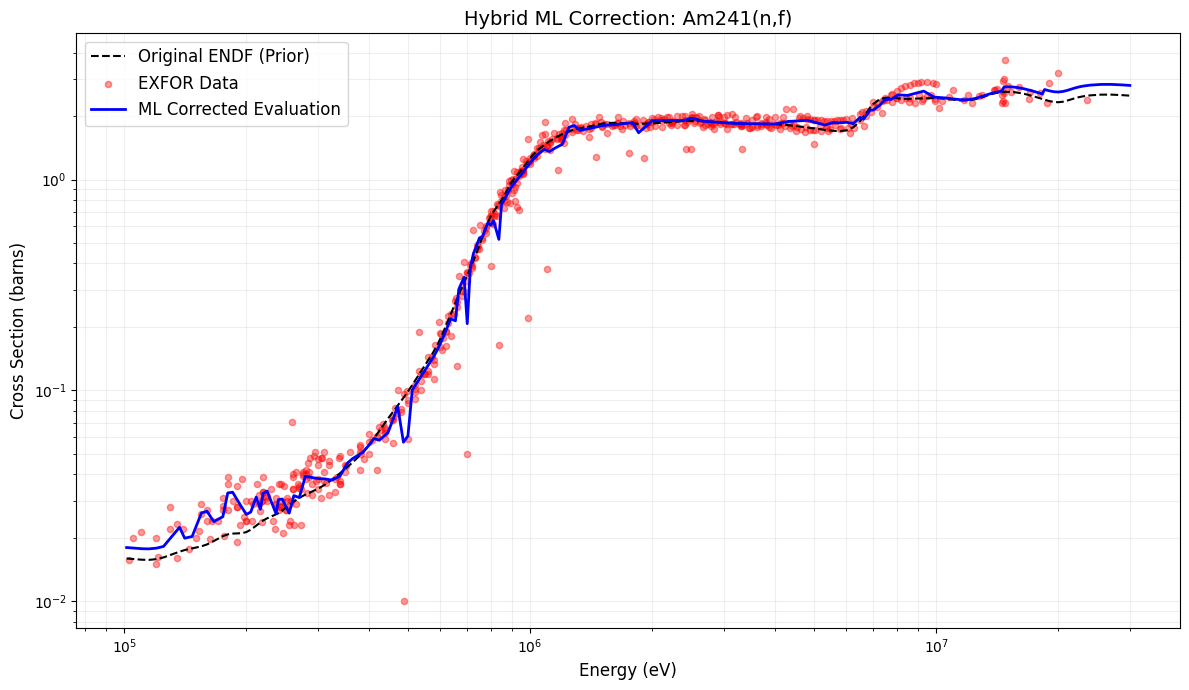

Plot generated.


In [9]:
# --- CELL 2.5: APPLY CORRECTION & PLOT ---
import matplotlib.pyplot as plt

print("Applying correction...")

# 1. Prepare Input for Prediction (The Full Eval Grid)
pred_input = df_eval[['log_e']].copy()
pred_input['log_e_squared'] = pred_input['log_e'] ** 2

# 2. Predict the Residual (The Correction)
predicted_residuals = res_model.predict(pred_input)

# 2. FIX ENERGY UNITS (MeV -> eV)
# If max energy is small (< 50), it's likely MeV.
if df_eval['energy'].max() < 50:
    print("--> Converting Energy from MeV to eV...")
    df_eval['energy'] *= 1e6

# Filter Fast Region
df_eval = df_eval[df_eval['energy'] > CUTOFF_EV].copy()

# 3. FIX CROSS-SECTION UNITS (Millibarns -> Barns)
# We compare the average (mean) of the Evaluation vs the Experiment
avg_eval = df_eval['sigma'].mean()
avg_exp = df_exp['sigma'].mean()

print(f"Average Eval Sigma: {avg_eval:.2f}")
print(f"Average Exp Sigma:  {avg_exp:.2f}")

# If Eval is > 100x larger than Exp, it's definitely Millibarns.
if avg_eval > (avg_exp * 100):
    print("--> DETECTED UNIT MISMATCH: Evaluation is in Millibarns.")
    print("--> Correcting: Dividing Evaluation by 1000.")
    df_eval['sigma'] = df_eval['sigma'] / 1000.0
else:
    print("--> Units appear aligned (Barns).")

# 3. Apply Correction
# New_Log_XS = Old_Log_XS + Predicted_Residual
df_eval['log_xs_corrected'] = df_eval['log_xs_eval'] + predicted_residuals

# Convert back to Barns (Linear space)
df_eval['sigma_corrected'] = 10 ** df_eval['log_xs_corrected']

# --- PLOTTING ---
plt.figure(figsize=(12, 7))

# A. Original Theory (Black Dashed)
plt.plot(df_eval['energy'], df_eval['sigma'], 
         color='black', linestyle='--', linewidth=1.5, label='Original ENDF (Prior)')

# B. Experimental Data (Red Dots)
plt.scatter(df_exp['energy'], df_exp['sigma'], 
            color='red', s=20, alpha=0.4, label='EXFOR Data')

# C. ML Corrected Result (Blue Line)
plt.plot(df_eval['energy'], df_eval['sigma_corrected'], 
         color='blue', linewidth=2, label='ML Corrected Evaluation')

# Styling
plt.xscale('log')
plt.yscale('log')
plt.title(f"Hybrid ML Correction: Am241(n,f)", fontsize=14)
plt.xlabel("Energy (eV)", fontsize=12)
plt.ylabel("Cross Section (barns)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.savefig("Am241_Final_Result.png", dpi=300)
plt.show()

print("Plot generated.")

## EXTRA 

In [ ]:
# --- BONUS: CALCULATE SACS INTEGRAL ---

def watt_spectrum(E_eV, a=0.988e6, b=2.249e-6):
    """
    Standard Watt Fission Spectrum approximation for U-235 / Cf-252.
    E_eV: Energy in eV
    Returns: Flux weight
    """
    E_MeV = E_eV / 1e6
    # Watt distribution formula: exp(-E/a) * sinh(sqrt(b*E))
    # Using standard parameter approximations for demonstration
    return np.exp(-E_eV/a) * np.sinh(np.sqrt(b*E_eV))

# 1. Calculate Weights
flux = watt_spectrum(df_eval['energy'])
dE = np.gradient(df_eval['energy'])

# 2. Integrate Original
numerator_orig = np.sum(df_eval['sigma'] * flux * dE)
denominator = np.sum(flux * dE)
sacs_orig = numerator_orig / denominator

# 3. Integrate Corrected
numerator_new = np.sum(df_eval['sigma_corrected'] * flux * dE)
sacs_new = numerator_new / denominator

print(f"--- Spectrum Averaged Cross Section (SACS) ---")
print(f"Original ENDF Estimate: {sacs_orig:.4f} barns")
print(f"ML Corrected Estimate:  {sacs_new:.4f} barns")
print(f"Change: {((sacs_new - sacs_orig)/sacs_orig)*100:.2f}%")

--- Spectrum Averaged Cross Section (SACS) ---
Original ENDF Estimate: 1.3858 barns
ML Corrected Estimate:  1.3798 barns
Change: -0.43%


: 